# 可视化文件夹中的图像

同济子豪兄 https://space.bilibili.com/1900783

代码运行[云GPU平台](https://featurize.cn/?s=d7ce99f842414bfcaea5662a97581bd1)

2022-7-31

## 导入工具包

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1 import ImageGrid
%matplotlib inline

import numpy as np
import math
import os

import cv2

from tqdm import tqdm

## 指定要可视化图像的文件夹

In [2]:
folder_path = 'fruit81_split/train/西瓜'

In [3]:
# 可视化图像的个数
N = 36

In [4]:
# n 行 n 列
n = math.floor(np.sqrt(N))
n

6

## 读取文件夹中的所有图像

In [6]:
images = []
for each_img in os.listdir(folder_path)[:N]:
    img_path = os.path.join(folder_path, each_img)
    img_bgr = cv2.imdecode(np.fromfile(img_path, dtype=np.uint8), -1)
    # 如果读取成功，再进行颜色空间转换
    if img_bgr is not None:
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        images.append(img_rgb)
    else:
        print(f"无法解码图像: {img_path}")
    

In [7]:
len(images)

36

## 画图

C:\Users\Leader\AppData\Local\Temp\ipykernel_35048\2833584570.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


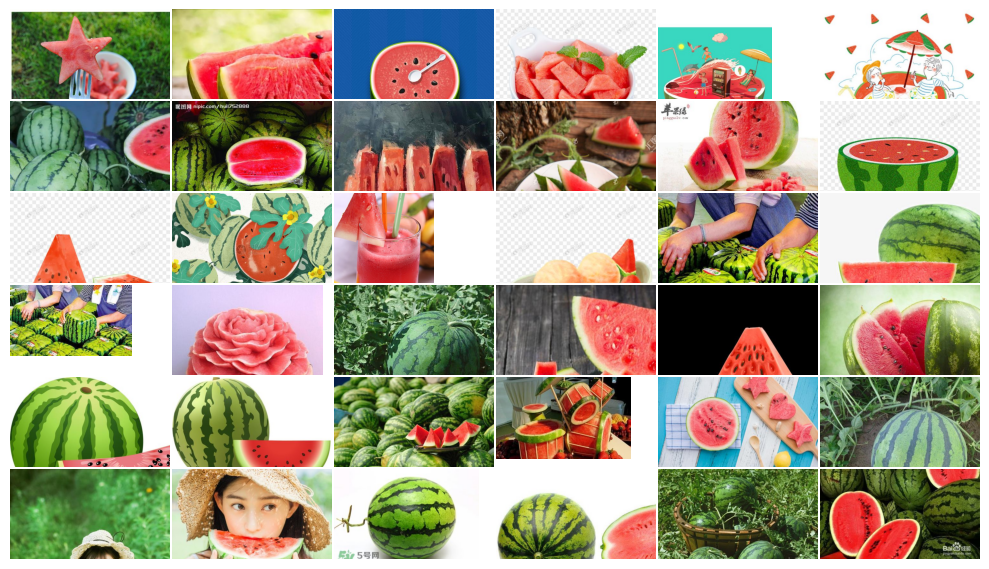

In [8]:
fig = plt.figure(figsize=(10, 10))
grid = ImageGrid(fig, 111,  # 类似绘制子图 subplot(111)
                 nrows_ncols=(n, n),  # 创建 n 行 m 列的 axes 网格
                 axes_pad=0.02,  # 网格间距
                 share_all=True
                 )

# 遍历每张图像
for ax, im in zip(grid, images):
    ax.imshow(im)
    ax.axis('off')

plt.tight_layout()
plt.show()